In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
import numpy as np
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support
from ocpc_py import MultiClassPC
import warnings
warnings.filterwarnings('ignore')
from lime.lime_tabular import LimeTabularExplainer
from xgboost import XGBClassifier
from keras.models import Sequential
from keras.layers import Dense
from keras.wrappers.scikit_learn import KerasClassifier

2024-10-01 16:40:03.765282: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-10-01 16:40:03.939110: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-10-01 16:40:05.000919: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


# Initial Functions and Load dataset

In [9]:

file_path = 'database_feature_extracted_3.xlsx'  
data = pd.read_excel(file_path)

label_counts = data['label'].value_counts().sort_index()
print(label_counts)
# data = data.dropna(axis=1)
# colunas_com_infinitos = data.columns[data.isin([np.inf, -np.inf]).any()]

# data = data.drop(columns=colunas_com_infinitos)
# data
y = data['label']
X = data.drop(columns=['label'], inplace=True)
X = data

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

oversampling = True

if oversampling:
    smote = SMOTE(random_state=42)
    X_train, y_train = smote.fit_resample(X_train, y_train)

    print("Contagens após o oversampling:")
    print(pd.Series(y_train).value_counts().sort_index())

label
0    103
1     69
2    111
3     38
4     48
5    111
Name: count, dtype: int64
Contagens após o oversampling:
label
0    91
1    91
2    91
3    91
4    91
5    91
Name: count, dtype: int64


In [11]:
explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns,
    class_names=[0, 1, 2, 3, 4, 5],
    mode='classification'
)

def build_analysis_model(model, name: str):

    for classe in range(0, 6, 1):
        yt = y_test[y_test.apply(lambda x: x == classe)]
        instances = X_test.loc[X_test.index.isin(yt.index)]

        feature_importances = []

        for _, instance in instances.iterrows():
            exp = explainer.explain_instance(instance.values, 
                                            model.predict_proba, 
                                            num_features=10, 
                                            labels=[0, 1, 2, 3, 4, 5])
            
            predicted_probs = exp.predict_proba
            predicted_class_index = predicted_probs.argmax()
            
            importance_dict = dict(exp.as_list(label=predicted_class_index))
            feature_importances.append(importance_dict)

        importances_df_list = []
        for importance_dict in feature_importances:
            df = pd.DataFrame(list(importance_dict.items()), columns=['Feature', 'Contribution'])
            importances_df_list.append(df)

        all_importances_df = pd.concat(importances_df_list)

        mean_importances_df = all_importances_df.groupby('Feature').mean().reset_index()
        mean_importances_df = mean_importances_df.sort_values(by='Contribution', ascending=False)

        top_5 = mean_importances_df.head(5)
        bottom_5 = mean_importances_df.tail(5)
        mean_importances_df = pd.concat([top_5, bottom_5])

        mean_importances_df['Color'] = mean_importances_df['Contribution'].apply(lambda x: 'blue' if x > 0 else 'red')
        
        plt.figure(figsize=(12, 6))
        sns.barplot(x='Contribution', y='Feature', data=mean_importances_df, palette=mean_importances_df['Color'].values)
        plt.title(f'Average Feature Contributions Across Multiple Instances for Intenção de Compra {classe}')

        plt.savefig(f'images/{name}/average_feature_contributions_intencao_de_compra{classe}.png', bbox_inches='tight', dpi=300)

        plt.close()


def run_model(model):

    scores = cross_val_score(model, X_train, y_train, cv=10)
    mean_score = scores.mean()
    std_dev_score = np.std(scores)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_pred)
    y_pred_proba = model.predict_proba(X_test)

    # Calcular a AUC usando a abordagem One-vs-Rest (OvR)
    auc_score = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average=None)

    print(f'AUC no conjunto de teste: {auc_score:.2f}')
    print(f'Validação Cruzada (10 folds) - Acurácia média: {mean_score:.2f}')
    print(f'Acurácia no conjunto de teste: {test_accuracy:.2f}')

    plt.figure(figsize=(5, 5))
    sns.boxplot(scores)
    plt.title('Boxplot of Cross Validation Accuracies')
    plt.xlabel('Scores')
    plt.show()

    mean_score = round(mean_score, 4)
    std_dev_score = round(std_dev_score, 4)
    auc_score = round(auc_score, 4)
    recall = round(recall.mean(), 4) 
    precision = round(precision.mean(), 4) 
    f1 = round(f1.mean(), 4) 
    test_accuracy = round(test_accuracy, 4)
    return scores, mean_score, std_dev_score, auc_score, recall, precision, f1, test_accuracy

# RandomForestClassifier

AUC no conjunto de teste: 0.88
Validação Cruzada (10 folds) - Acurácia média: 0.74
Acurácia no conjunto de teste: 0.60


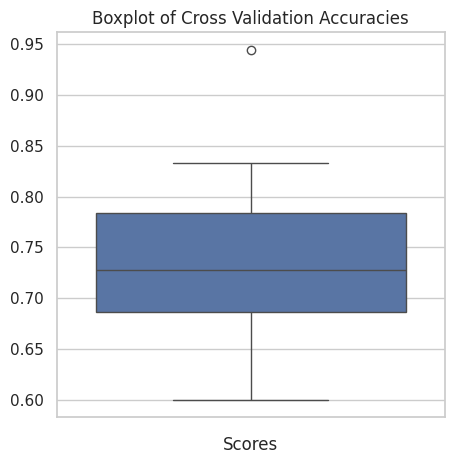

In [12]:
model_rf = RandomForestClassifier()

(scores_rf, 
 mean_score_rf, 
 std_dev_score_rf, 
 auc_score_rf, 
 recall_rf, 
 precision_rf, 
 f1_rf, 
 test_accuracy_rf) = run_model(model=model_rf)

In [ ]:
# build_analysis_model(model=model_rf, name='random_forest')

# ExtraTreesClassifier

AUC no conjunto de teste: 0.86
Validação Cruzada (10 folds) - Acurácia média: 0.76
Acurácia no conjunto de teste: 0.64


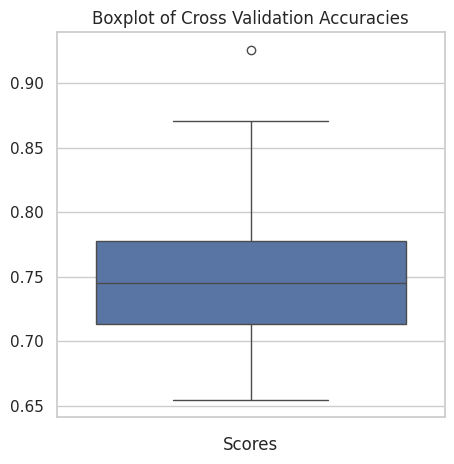

In [13]:
model_extra_tree = ExtraTreesClassifier()

(scores_extra_tree, 
 mean_score_extra_tree, 
 std_dev_score_extra_tree, 
 auc_score_extra_tree, 
 recall_extra_tree, 
 precision_extra_tree, 
 f1_extra_tree, 
 test_accuracy_extra_tree) = run_model(model=model_extra_tree)

# MLP

Epoch 1/20
491/491 [==============================] - 2s 1ms/step - loss: 302960312320.0000 - accuracy: 0.1568
Epoch 2/20
491/491 [==============================] - 1s 1ms/step - loss: 1.7928 - accuracy: 0.1568
Epoch 3/20
491/491 [==============================] - 1s 1ms/step - loss: 1.7919 - accuracy: 0.1385
Epoch 4/20
491/491 [==============================] - 1s 1ms/step - loss: 1.7912 - accuracy: 0.1629
Epoch 5/20
491/491 [==============================] - 1s 1ms/step - loss: 1.7910 - accuracy: 0.1792
Epoch 6/20
491/491 [==============================] - 1s 1ms/step - loss: 1.7907 - accuracy: 0.1527
Epoch 7/20
491/491 [==============================] - 1s 1ms/step - loss: 1.7904 - accuracy: 0.1609
Epoch 8/20
491/491 [==============================] - 1s 1ms/step - loss: 1.7905 - accuracy: 0.1690
Epoch 9/20
491/491 [==============================] - 1s 1ms/step - loss: 1.7905 - accuracy: 0.1629
Epoch 10/20
491/491 [==============================] - 1s 1ms/step - loss: 1.7903 - accur

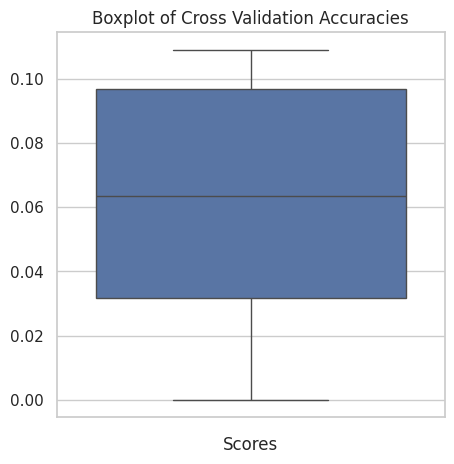

array([0.05454545, 0.10909091, 0.10909091, 0.03636364, 0.07272727,
       0.01818182, 0.09259259,        nan,        nan, 0.        ])

In [26]:
def create_model():
    model = Sequential([
        Dense(126, activation='relu', input_shape=(X_train.shape[1],)),
        Dense(126, activation='relu'),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(32, activation='relu'),
        Dense(len(np.unique(y)), activation='softmax')
    ])
    model.compile(optimizer='nadam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model_mlp = KerasClassifier(build_fn=create_model, epochs=20, batch_size=1, verbose=1)

(scores_mlp, 
 mean_score_mlp, 
 std_dev_score_mlp, 
 auc_score_mlp, 
 recall_mlp, 
 precision_mlp, 
 f1_mlp, 
 test_accuracy_mlp) = run_model(model=model_mlp)

mean_score_mlp = round(scores_mlp[~np.isnan(scores_mlp)].mean(), 4)
scores_mlp

# LinearDiscriminantAnalysis

AUC no conjunto de teste: 0.72
Validação Cruzada (10 folds) - Acurácia média: 0.46
Acurácia no conjunto de teste: 0.32


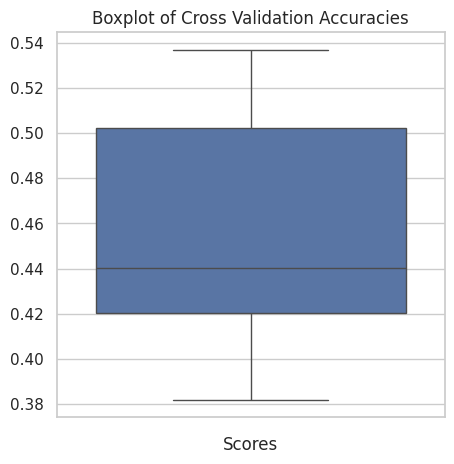

In [15]:
model_linear = LinearDiscriminantAnalysis()

(scores_linear, 
 mean_score_linear, 
 std_dev_score_linear, 
 auc_score_linear, 
 recall_linear, 
 precision_linear, 
 f1_linear, 
 test_accuracy_linear) = run_model(model=model_linear)

# ocpc_py

In [16]:

model = MultiClassPC(k_max=10, alfa=0.1, lamda=0.5, buffer=200)

kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scores = []
auc_scores = []

for train_index, val_index in kf.split(X_train, y_train):
    X_train_fold, X_val_fold = X_train.iloc[train_index].to_numpy(), X_train.iloc[val_index].to_numpy()
    y_train_fold, y_val_fold = y_train.iloc[train_index].to_numpy(), y_train.iloc[val_index].to_numpy()
    
    model.fit(X_train_fold, y_train_fold)
    
    y_val_pred = model.predict(X_val_fold)
    
    accuracy = accuracy_score(y_val_fold, y_val_pred)
    scores.append(accuracy)
    
    y_val_proba = model.predict_proba(X_val_fold)
    auc = roc_auc_score(pd.get_dummies(y_val_fold), y_val_proba, multi_class='ovr')
    auc_scores.append(auc)

model.fit(X_train.to_numpy(), y_train.to_numpy())

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

test_auc = roc_auc_score(pd.get_dummies(y_test), y_pred_proba, multi_class='ovr')

test_accuracy = accuracy_score(y_test, y_pred)

auc_score = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average=None)

print(f'Validação Cruzada (10 folds) - Acurácia média: {np.mean(scores):.2f}')
print(f'AUC média na validação: {np.mean(auc_scores):.2f}')
print(f'Acurácia no conjunto de teste: {test_accuracy:.2f}')
print(f'AUC no conjunto de teste: {test_auc:.2f}')

plt.figure(figsize=(10, 6))
sns.boxplot(scores)
plt.title('Boxplot dos Scores de Validação Cruzada')
plt.xlabel('Acurácia')
plt.legend()
plt.show()

scores_ocpc = scores 
mean_score_ocpc = round(np.mean(scores), 4)
std_dev_score_ocpc = round(np.std(scores), 4)
auc_score_ocpc = round(auc_score, 4)
recall_ocpc = round(recall.mean(), 4)
precision_ocpc = round(precision.mean(), 4)
f1_ocpc = round(f1.mean(), 4)
test_accuracy_ocpc = round(test_accuracy, 4)


IndexError: index 0 is out of bounds for axis 0 with size 0